# An advertising dataset

This [Advertising dataset](https://raw.githubusercontent.com/nguyen-toan/ISLR/master/dataset/Advertising.csv), originally featured in [An Introduction to Statistical Learning](https://www.statlearning.com/), contains sales data for a product across 200 different markets, along with advertising budgets (in thousands of dollars) allocated to TV, radio, and newspaper campaigns in each market. This dataset is widely used in introductory statistics and data science courses to demonstrate the principles of linear regression. Its clean structure and clear relationships between variables—especially between TV advertising and sales—make it ideal for exploring how marketing investments influence consumer behavior and product performance.

In [ ]:
# Load the Advertising dataset
import pandas as pd
url = "https://raw.githubusercontent.com/nguyen-toan/ISLR/master/dataset/Advertising.csv"
df = pd.read_csv(url)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


## Practice

Perform initial data exploration using skills we learned before. No visualization is needed. Add more code blocks as needed.

In [ ]:
df.head(10)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


**Add a text block** to explain what you learn about the dataset via data exploration

# Scatter plot

As a reminder, scatter plots are helpful for exploring relationships between two numerical variables. The following code block shows key parameters of the `plot` function when creating a scatter plot.

*  Set the `kind` parameter to `'scatter'`.
*  The `x` parameter specifies the column whose values will be used for the x-axis.
*  The `y` parameter specifies the column whose values will be used for the y-axis.
*  The `figsize` parameter specifies the width and height of the figure.
*  The `alpha` parameter specifies the level of transparency for each dot, 0 for fully transparent and 1 for fully opaque. The default value is 1.
*  The `s` parameter specifies the size of the dots, 20 for a small dot, 50 - 80 for a medium dot, and 150 - 300 for a large dot.
*  The `grid` parameter specifies whether to show a grid in the background. The default value is `False`.

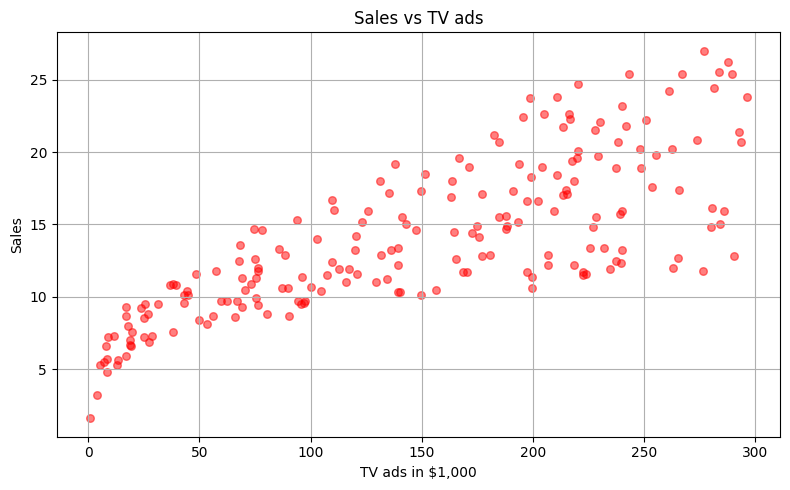

In [ ]:
import matplotlib.pyplot as plt

# create a scatter plot
df.plot(kind='scatter',             #Indicate the kind of plot to be generated
        x='TV',                     #Identify the column for the x-axis
        y='Sales',                  #Identify the column for the y_axis
        figsize=(8, 5),
        title='Sales vs TV ads',
        xlabel='TV ads in $1,000',
        s=30,                       #Indicate the size of each dot
        alpha=0.5,                  #Indicate the level of transparency
        color='red',                #Indicate the color for the dots
        grid=True                   #Decide whether to use grid
)

plt.tight_layout()
plt.show()

Here are a few patterns we can observe from the above scatter plot:

*  Sales seem to go up when more funds were invested in TV ads.
*  There's less variation in sales when TV ad spending was less than 100 thousand dollars.
*  There's more variation in sales when TV ad spending was higher than 200 thousand dollars.

## Practice

In [ ]:
# Create a scatter plot for Sales versus Radio advertising budget


In [ ]:
# Create a scatter plot for Sales versus Newspaper advertising budget


Add a **text block** to explain what you learn about the dataset via the scatter plots

# Simple linear regression

**ANOVA tests** examine whether a categorical, independent variable has an effect on a numeric, dependent variable. A **simple linear regression** is commonly used to examine relationship between **two numeric variables**.
A Simple Linear regression model uses a **straight line** to estimate the relationship between two **quantitative** variables. These variables are referred to as **independent (input, x)** and **dependent (output, y)** variables. The following figure illustrates simple linear regression.

<img src='https://realpython.com/cdn-cgi/image/width=950,format=auto/https://files.realpython.com/media/fig-lin-reg.a506035b654a.png' width=550>

There are a few important vocabulary to review for Simple Linear Regression:
*  **independent** or **input variable**: the variable on the **x-axis**.
*  **dependent** or **output variable**: the variable on the **y-axis**.
*  **linear regression model**: the line shown on the graph. It is represented by a function $f(x) = b_0 + b_1 x$. Each **green dot** reflects an original pair of independent/input and dependent/output values. Each **red dot** marks the predicted dependent/output value for a given independent/input value.
*  **intercept**: the y-value where the line intercepts with the y-axis. It is noted as $b_0$ in the above function.
*  **coeffient** or **slope**: how the line tilt from the x-axis. It is noted as $b_1$ in the above function.
*  **residual** or **error**: the difference in y-values between the green and red dots for a given x-value.

The goal of simple linear regression is to calculate the optimal values of the intercept $b_0$ and slope $b_1$ that minimize the Sum of Squared Rediduals (SSR). In another word, we are looking for a line that can best fit the dots on a scatter plot.



# Perform Linear Regression

We have used the ols ( **Ordinary Least Squares**) function for ANOVA. As a reminder,
*  The `formula` parameter uses a specially structured string to specify the independent (input) and dependent (output) variables. The one before ~ is the dependent (output) variable and the one after ~ is the independent (input) variable.
*  The `data` parameter specifies the DataFrame from which the variables come.

For ANOVA, the independent variables are categorical columns. When using ols for linear regression, the independent variables are also numeric columns.

The `fit` function is called to look for the best intercept and slope for the linear regression.

The `summary` function returns details of lineary regression model. Here are a few things we should pay attention to.

*  **Dep. Variable**: This shows the dependent variable of the model.
*  **No. Observations**: This shows the number of data points used in the model.
*  **F-statistics**: Test the overall significance of themodel. A higher value indicates that the model is a good fit.
*  **Prob (F-statistics)**: A low p-value indicates that the model is statistically significant.
*  **R-squared**: This indicates the proportion of variance in the dependent variable that is predictable from the independent variable. Values range from 0 to 1, with higher values indicating a better fit.
*  **coef**: This estimates coefficients for the intercept ($b_0$) and the slope ($b_1$). In this case, the model would set one's self esteem level to 2.8768 when they have no family satisfaction. Each additional level of family satisfaction would increase 0.3607 of self esteem.
*  **P>|t|**: This is the P-value for whether each coefficient is significantly different from zero.

In [ ]:
from statsmodels.formula.api import ols

# Sales is the dependent (output) variable
# TV is the independent (input) variable
tv_model = ols(formula='Sales ~ TV', data=df).fit()

# Show a summary of the model
tv_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           1.47e-42
Time:                        16:11:39   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0326      0.458     15.360      0.000       6.130       7.935
TV             0.0475      0.003     17.668      0.000       0.042       0.053
==============================================================================
Omnibus:                        0.531   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.767   Jarque-Bera (JB):                0.669
Skew:                          -0.089   Prob(JB):                        0.716
Kurtosis:                       2.779   Cond. No.                         338.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Here are observations about the data from the above regression results

*  Dep. Variable: The dependent variable is Sale.
*  No. Obsrevations: The number of observations is 200.
*  Df Model: Only one predictor (independent variable) is used.
*  R-Squared: About 61.2% (0.612) of the variation in Sales is explained by TV advertising.
*  Adj. R-squared: 0.610 is very close to R-Squared. So the model is stable.
*  F-statistics: 312.1 is a pretty large value, showing the model is explaining a significant amount of variance.
*  Prob (F-statistic): 1.47e-42 is a very small value. Indicating the model is statistically significant.
*  Intercept coef: $b_0$ is 7.0326, indicating the model sets Sales to 3.275 when TV is 0.
*  TV coef: $b_1$ is 0.0475, indicating that the model will increase Sales by 0.0475 when TV ad is creased by 1 unit.
*  P>|t| values are very small, indicating the above coefficients are likely to be meaningful predictors.

## Practice

In [ ]:
#Create a linear regression model with Sales as the dependent variable and Radio as the independent variable
#Call the summary function to show the detailed results of the model


In [ ]:
#Create a linear regression model with Sales as the dependent variable and Newspaper as the independent variable
#Call the summary function to show the detailed results of the model


**Add a text box** to identify the following values for each model: R-Squared, Adj. R-Squared, F-statitics, Prob(F-statistic), $b_0$ (intercept), and $b_1$ (coefficient/slop).

# Line plot

The intercept $b_0$ and slop $b_1$ are used by the model to create fitted values of the dependent variable based on the values of the independent variable.

In [ ]:
df['fitted_sales'] = tv_model.fittedvalues
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales,fitted_sales
0,1,230.1,37.8,69.2,22.1,17.970775
1,2,44.5,39.3,45.1,10.4,9.147974
2,3,17.2,45.9,69.3,9.3,7.850224
3,4,151.5,41.3,58.5,18.5,14.234395
4,5,180.8,10.8,58.4,12.9,15.627218


We can see from the above few rows that some fitted values are closer to the observed values then others. Some are larger than the observed values while others are less than the observed values.

We can create a line plot to show that relationship between the fitted values and the observed independent variable's values.

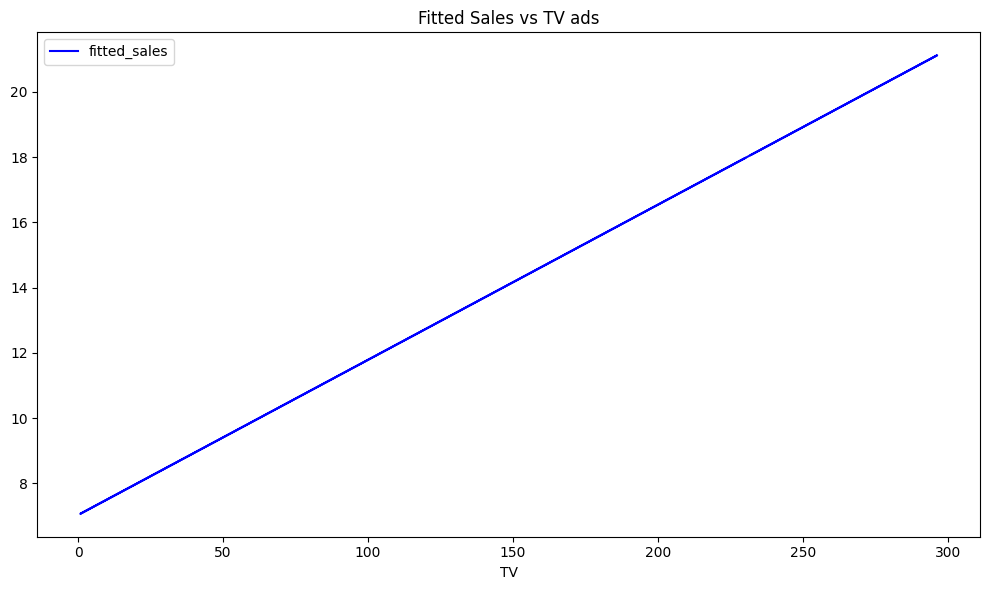

In [ ]:
import matplotlib.pyplot as plt

df.plot(kind='line',         #Indicate the kind of plot to be generated
        x='TV',              #Identify the column for the x-axis
        y='fitted_sales',    #Identify the column for the y_axis
        title='Fitted Sales vs TV ads',
        figsize=(8, 5),
        color='blue')

plt.tight_layout()
plt.show()

# Combine scattter and line plots

The following code block shows how we can combine scatter plot and line plot in the same figure.

Each call of the `plot` function returns an Axes object that represents the actual plotting area where the plot is drawn. When drawing a new plot, we can specify the `ax` parameter for the new plot to add the new plot in the same Axes object.

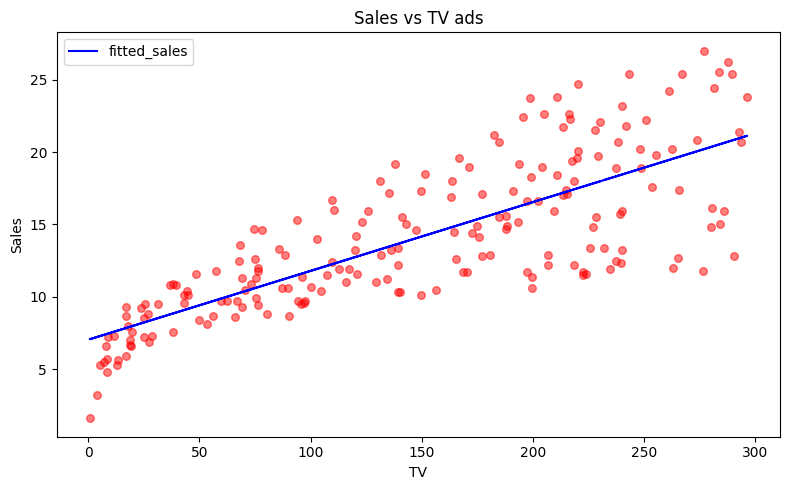

In [ ]:
import matplotlib.pyplot as plt
df['fitted_sales'] = tv_model.fittedvalues
# create a scatter plot
scatter_ax = df.plot(kind='scatter',    #Indicate the kind of plot to be generated
        x='TV',                     #Identify the column for the x-axis
        y='Sales',                  #Identify the column for the y_axis
        figsize=(8, 5),             #Set up the width and height of the graph
        title='Sales vs TV ads',    #Set up the title of the graph
        s=30,                       #Indicate the size of each dot
        alpha=0.5,                  #Indicate the level of transparency
        color='red'                 #Indicate the color for the dots
        )

df.plot(kind='line',        #Indicate the kind of plot to be generated
        x='TV',             #Identify the column for the x-axis
        y='fitted_sales',   #Identify the column for the y_axis
        ax=scatter_ax,      #Identify where to draw the plot
        color='blue'        #Indicate the color for the line
        )

plt.tight_layout()
plt.show()

This visualization helps us compare the ideal linear regression line against the actual data. The scatter plot shows the raw data while the regression line summarizes the overall linear relationship.

*  While some dots (markets) fall on the line, most do not.
*  The linear regression model under-predicted for the markets that are above the line.
*  The linear regression model over-predicted for the markets that are under the line.
*  The distance vertical distance between each dot and the line is considered an "error", or "residual". The regression line is chosen to minimize the squared residuals. The R-Square value is derived from these errors/residuals to summarize how close the dots tend to be to the line. The tighter cluster around line, the higher R-Square. The wider vertical spread, the lower R-Square.

## Practice

In [ ]:
# Create a fitted value column for Radio


# Generate a combined scatter and line plot to illustrate the linear model


In [ ]:
# Create a fitted value column for Newspaper


# Generate a combined scatter and line plot to illustrate the linear model


**Add a text block** to compare the linear regression model for Sales against all three advertisement. Does one regression model fit better/worse than the others? Did the three advertisement methods contribute similarly to sales? Why?

# Reflection

In a text block, explain what you think about linear regression. How do you see it related to studies/research that may be performed in your field?